In [3]:
pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 75.6 MB/s eta 0:00:00


In [4]:
import rasterio
import numpy as np
import pandas as pd
from rasterio.windows import Window
import matplotlib.pyplot as plt

In [5]:
import rasterio
import numpy as np

# Load Rasters
with rasterio.open('/content/2019cdl_matched2sentinel.tif') as src1:
    gt = src1.read(1)

with rasterio.open('/content/fullseason28_cropland_mask.tif') as src2:
    pred = src2.read(1)

# Ensure binary masks (0,1)
gt = (gt > 0).astype(int)
pred = (pred > 0).astype(int)

# Calculate Intersection & Union
intersection = np.logical_and(gt, pred).sum()
union = np.logical_or(gt, pred).sum()

iou = intersection / union

print(f"IoU Score: {iou:.4f}")

IoU Score: 0.5146


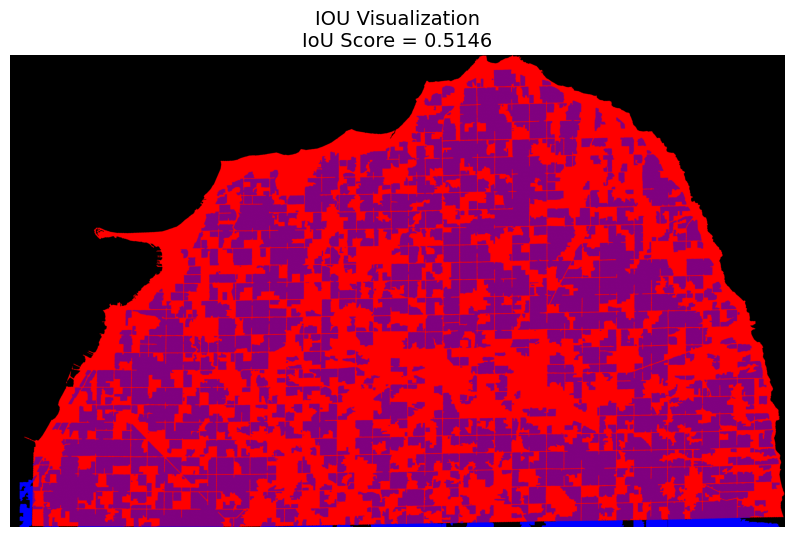

In [6]:
##Visual Output of IoU Concept

visual = np.zeros_like(gt, dtype=np.uint8)

visual[np.logical_and(gt == 1, pred == 1)] = 3  # Intersection → Purple
visual[np.logical_and(gt == 1, pred == 0)] = 1  # GT only → Red
visual[np.logical_and(gt == 0, pred == 1)] = 2  # Prediction only → Blue

# Define custom colormap
from matplotlib.colors import ListedColormap

cmap = ListedColormap([
    'black',    # 0 → background
    'red',      # 1 → ground truth only
    'blue',     # 2 → prediction only
    'purple'    # 3 → intersection
])

# Plot
plt.figure(figsize=(10, 10))
plt.imshow(visual, cmap=cmap)
plt.title(f"IOU Visualization\nIoU Score = {iou:.4f}", fontsize=14)
plt.axis('off')
plt.show()